In [1]:
%cd ..

f:\nn


# Importing Libraries

In [2]:
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Visualizing Images

In [3]:
df = pd.read_csv('data/images_path.csv')

display(df.head())
print("="*50)
display(df['class'].value_counts())

,path,class
0,data\Bangunan Retak\Cracked\00001.jpg,Cracked
1,data\Bangunan Retak\Cracked\00002.jpg,Cracked
2,data\Bangunan Retak\Cracked\00003.jpg,Cracked
3,data\Bangunan Retak\Cracked\00004.jpg,Cracked
4,data\Bangunan Retak\Cracked\00005.jpg,Cracked


class
Non Cracked    67608
Cracked        28484
Name: count, dtype: int64

# Visualizing and gathering information about images

Image size:  (227, 227)


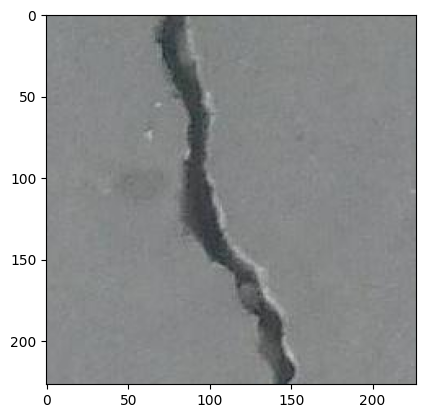

In [4]:
img = Image.open(df['path'][0])
plt.imshow(img)
print("="*50)
print("Image size: ", img.size)

# Ensuring that all images have the same size

In [5]:
image_size = set()
for path in df['path']:
    img = Image.open(path)
    image_size.add(img.size)
print("Unique image sizes: ", image_size)

Unique image sizes:  {(256, 256), (227, 227)}


In [6]:
x = 0
y = 0

for path in df['path']:
    img = Image.open(path)
    if img.size == (256,256):
        x += 1
    else:
        y += 1


print("Number of images with size (256,256): ", x)
print("Number of images with size (227,227): ", y)

Number of images with size (256,256):  56092
Number of images with size (227,227):  40000


The dataset contains images with different dimensions, mainly (256, 256) and (227, 227), so preprocessing is required before model training. To ensure consistent input, all images should be `resized to a fixed shape`. For **CNN**, resized images can be used directly, while for **FFNN**, the resized images should be `flattened` into vectors. For **RNN**, resizing is also required, with the input then reshaped according to the sequence format used by the model.

# Visualizing a grid of images

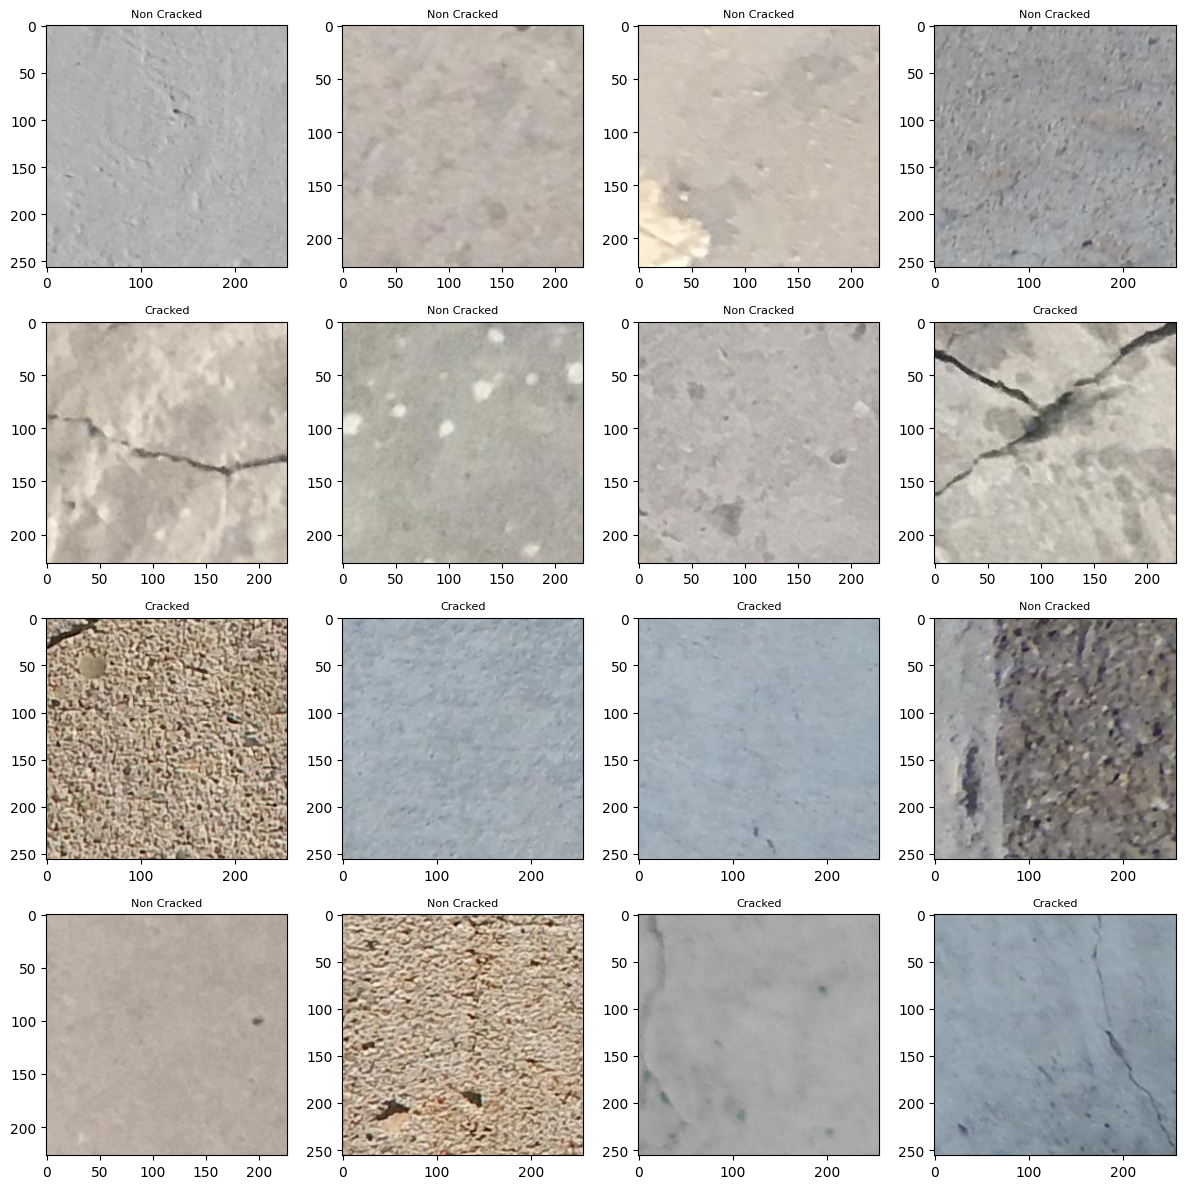

In [7]:
plt.figure(figsize=(12, 12))

sample_df = df.sample(16, random_state=21)

for i in range(16):
    img_path = sample_df.iloc[i]['path']
    label = sample_df.iloc[i]['class']

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=8)

plt.tight_layout()
plt.show()